## Core collapse SN 2019ehk in NGC4321

In [200]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import functions
import importlib
importlib.reload(functions)

from functions import *
from astropy.io import fits

In [201]:
file_path = '../../DATA/SN2019ehk/'#'../../DATA/SN2011jm/'
#

na_rest=(5890+5896)/2
K_I = 7699
DIB_I = 8621
DIB_II = 8648
DIB_III=5780
central_wavelength = na_rest


#z=0.003197
z=0.00525

In [202]:
from astropy.time import Time

def to_jd(year, month, day, hour=0, minute=0, second=0):
    date = f"{year:04d}-{month:02d}-{day:02d}T{hour:02d}:{minute:02d}:{second:02d}"
    return Time(date, format="isot").jd

### preparing SN spectra of each epoch

In [146]:
from pathlib import Path

directory = Path(file_path+"SNe-spectra/")

filenames = [f.name for f in directory.iterdir() if f.is_file()]

In [147]:
filenames

['2019ehk_2458610.0236_BAO-2.16m_Cassegrain_None.fits',
 '2019ehk_2458604.1332_BAO-2.16m_Cassegrain_None.fits',
 '2019ehk_2458613.0768_BAO-2.16m_Cassegrain_None.fits',
 'SN2019ehk_2019-04-30_06-13-31_Lick-3m_KAST_TNS.dat',
 'SN2019ehk_2019-05-08_23-17-20_P60_SEDM_TNS.ascii',
 '2019ehk_2019-05-13_00-00-00_P200_DBSP_None.txt',
 '2019ehk_2458606.1991_BAO-2.16m_Cassegrain_None.fits',
 '2019ehk_2458609.1449_BAO-2.16m_Cassegrain_None.fits',
 '2019ehk_2458608.0076_BAO-2.16m_Cassegrain_None.fits']

storing all SNe epochs spectra into one npz file

In [78]:
spectra = []

reading dat file

In [79]:
file = Path(file_path) / 'SN2019ehk_2019-04-30_06-13-31_Lick-3m_KAST_TNS.dat'

df = pd.read_csv(file, sep=r"\s+", header=None)
x = df.iloc[:, 0].to_numpy()
y = df.iloc[:, 1].to_numpy()
jd = to_jd(2019,4,30,6,13,31)

spectra.append({"file": file,"julian_date": jd,"x": x,"y": y})

reading fits files

In [80]:
fits_files = [f for f in filenames if f.endswith(".fits")]

In [81]:

for name in fits_files:

    file = Path(file_path) / name
    if name == "SN2019ehk.fits":
        continue
    with fits.open(file) as hdul:
        y = hdul[0].data
        header = hdul[0].header
        
        NAXIS = int(header["NAXIS1"])
        CRVAL = float(header["CRVAL1"])
        CDELT = float(header["CDELT1"])
        CRPIX = float(header["CRPIX1"])
        x = CRVAL + CDELT * (np.arange(NAXIS) + 1 - CRPIX)
        jd = header["JD"]
    if int(float(jd)) > 2458700:
        continue
    spectra.append({"file": file,"julian_date": jd,"x": x,"y": y})

reading ascii files

In [82]:
file = Path(file_path) / 'SN2019ehk_2019-05-08_23-17-20_P60_SEDM_TNS.ascii'

data = np.loadtxt(file, comments="#")

x = data[:, 0]
y = data[:, 1]
jd = to_jd(2019,5,8,23,17,20)

spectra.append({"file": file,"julian_date": jd,"x": x,"y": y})

reading txt files

In [83]:
file = Path(file_path) / "2019ehk_2019-05-13_00-00-00_P200_DBSP_None.txt"


data = np.loadtxt(file, comments="#")

x = data[:, 0]
y = data[:, 1]
jd = to_jd(2019,5,13,0,0,0)

spectra.append({"file": file,"julian_date": jd,"x": x,"y": y})

In [84]:
len(spectra)

8

In [85]:
np.save("spectra.npy", spectra, allow_pickle=True)

### measuring EW for each epoch

In [148]:
for spec in spectra:
    
    print(spec["file"])

../../DATA/SN2019ehk/SNe-spectra/SN2019ehk_2019-04-30_06-13-31_Lick-3m_KAST_TNS.dat
../../DATA/SN2019ehk/SNe-spectra/2019ehk_2458610.0236_BAO-2.16m_Cassegrain_None.fits
../../DATA/SN2019ehk/SNe-spectra/2019ehk_2458613.0768_BAO-2.16m_Cassegrain_None.fits
../../DATA/SN2019ehk/SNe-spectra/2019ehk_2458606.1991_BAO-2.16m_Cassegrain_None.fits
../../DATA/SN2019ehk/SNe-spectra/2019ehk_2458609.1449_BAO-2.16m_Cassegrain_None.fits
../../DATA/SN2019ehk/SNe-spectra/2019ehk_2458608.0076_BAO-2.16m_Cassegrain_None.fits
../../DATA/SN2019ehk/SNe-spectra/SN2019ehk_2019-05-08_23-17-20_P60_SEDM_TNS.ascii
../../DATA/SN2019ehk/SNe-spectra/2019ehk_2019-05-13_00-00-00_P200_DBSP_None.txt


../../DATA/SN2019ehk/SNe-spectra/SN2019ehk_2019-04-30_06-13-31_Lick-3m_KAST_TNS.dat
<class 'numpy.ndarray'>
len of chopped data is  154 154


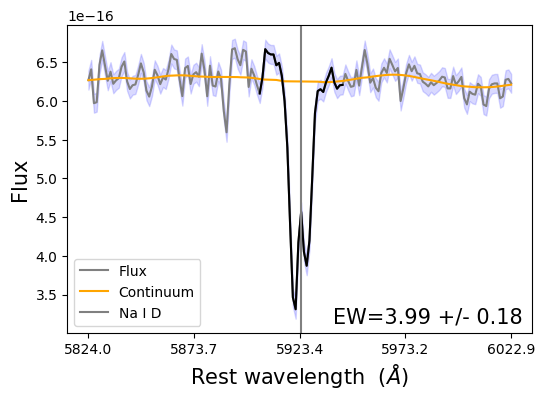


EW = 3.99  +/-  0.18447404831024763
../../DATA/SN2019ehk/SNe-spectra/2019ehk_2458610.0236_BAO-2.16m_Cassegrain_None.fits
<class 'numpy.ndarray'>
len of chopped data is  72 72


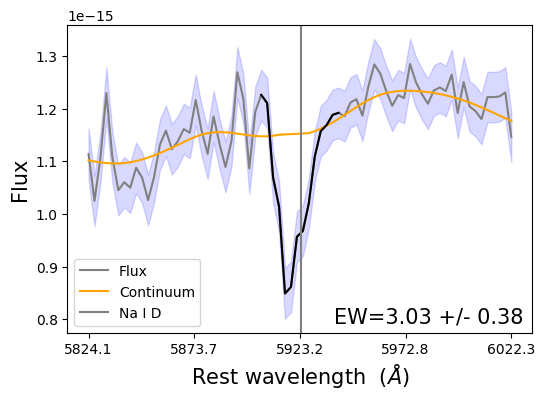


EW = 3.03  +/-  0.3813238451631532
../../DATA/SN2019ehk/SNe-spectra/2019ehk_2458613.0768_BAO-2.16m_Cassegrain_None.fits
<class 'numpy.ndarray'>
len of chopped data is  71 71


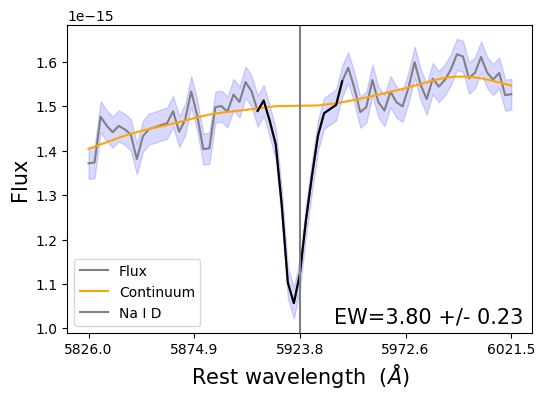


EW = 3.80  +/-  0.22620625398698366
../../DATA/SN2019ehk/SNe-spectra/2019ehk_2458606.1991_BAO-2.16m_Cassegrain_None.fits
<class 'numpy.ndarray'>
len of chopped data is  73 73


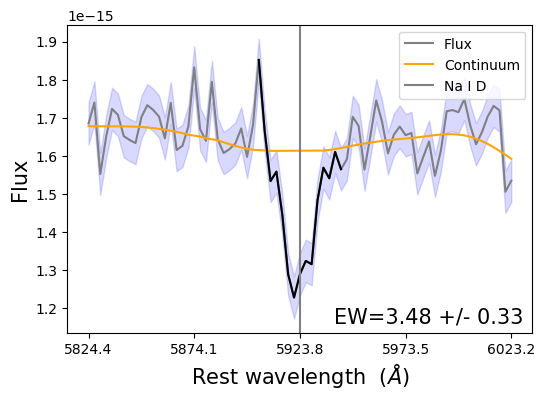


EW = 3.48  +/-  0.3256766098112325
../../DATA/SN2019ehk/SNe-spectra/2019ehk_2458609.1449_BAO-2.16m_Cassegrain_None.fits
<class 'numpy.ndarray'>
len of chopped data is  72 72


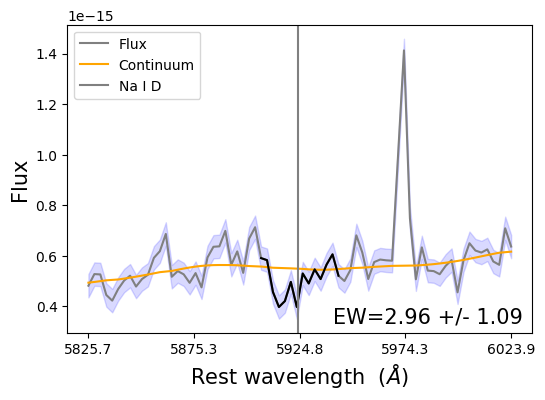


EW = 2.96  +/-  1.086348585607199
../../DATA/SN2019ehk/SNe-spectra/2019ehk_2458608.0076_BAO-2.16m_Cassegrain_None.fits
<class 'numpy.ndarray'>
len of chopped data is  71 71


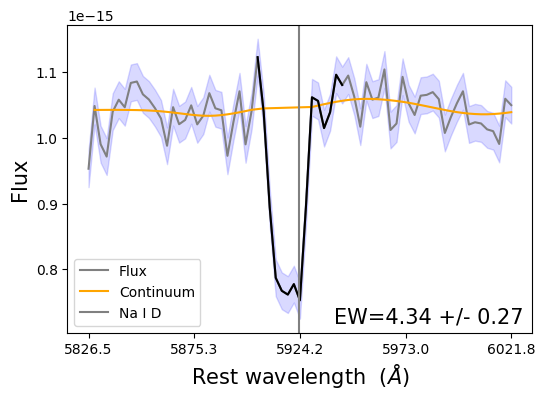


EW = 4.34  +/-  0.27028572408044876
../../DATA/SN2019ehk/SNe-spectra/2019ehk_2019-05-13_00-00-00_P200_DBSP_None.txt
<class 'numpy.ndarray'>
len of chopped data is  132 132


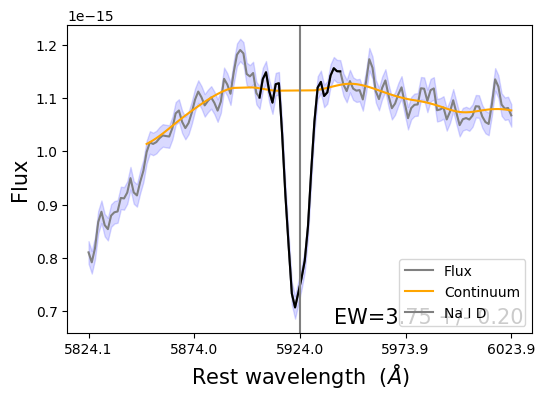


EW = 3.75  +/-  0.2002591899397397


In [149]:
spectra = np.load("spectra.npy", allow_pickle=True)

ews = []
ews_uncs = []
jds = []
i=0
for spec in spectra:

    i+=1
    if i==7: #this file has very low resolution, its the ascii file
        continue
    
    print(spec["file"])
    x = spec["x"]
    y = spec["y"]
    
    print(type(x))
    #if central_wavelength*(1+z)>np.max(x) or central_wavelength*(1+z)<np.min(x):
    #    continue
    
    
    ew,ew_unc,foo=EW_voronoi_bins(np.array([y]),x,central_wavelength*(1+z),v=1000,KS=30,plots=True)
    
    ews.append(ew[0])
    ews_uncs.append(ew_unc[0])
    jds.append(spec["julian_date"])
    
    

In [134]:
jds = np.array(jds, dtype=float)

mjd = jds - 2400000.5

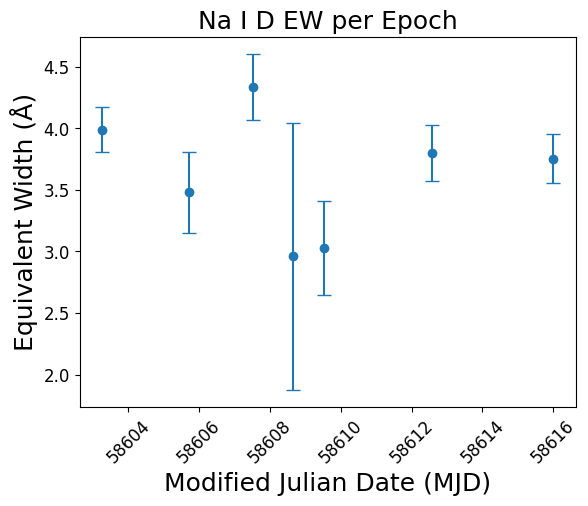

In [141]:
plt.errorbar(mjd, ews, yerr=ews_uncs, fmt='o', capsize=5)
plt.title("Na I D EW per Epoch",fontsize=18)
plt.xlabel("Modified Julian Date (MJD)",fontsize=18)
plt.ylabel("Equivalent Width (Å)",fontsize=18)

plt.tick_params(axis='both', labelsize=12)
plt.ticklabel_format(axis='x', style='plain', useOffset=False)
plt.xticks(rotation=45)
plt.savefig("SN2019time-variability.pdf", bbox_inches='tight')

In [30]:
#df = pd.read_csv(file_path+filenames[0], sep=r"\s+", header=None)

In [31]:
x = df.iloc[:, 0].to_numpy()
y = df.iloc[:, 1].to_numpy()

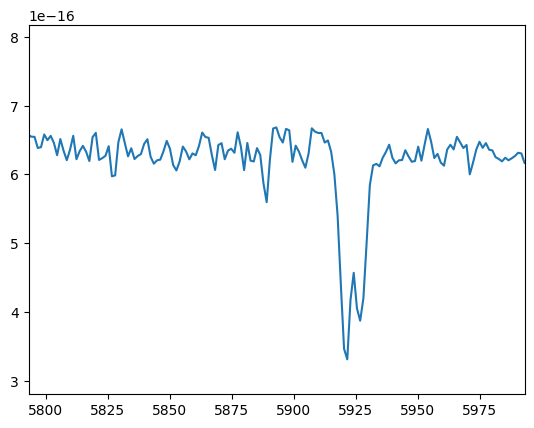

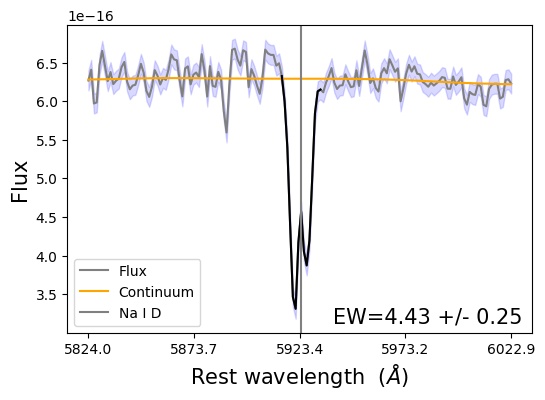


EW = 4.43  +/-  0.25375636819033


([np.float64(4.428350063001031)],
 [np.float64(0.25375636819033)],
 [np.float64(8058.1528681531945)])

In [32]:
plt.plot(x,y)
plt.xlim(central_wavelength-100,central_wavelength+100)
#plt.axvline(x=central_wavelength*(1+z),color='red')

EW_voronoi_bins(np.array([y]),x,central_wavelength*(1+z),v=500,KS=100,plots=True)


## MUSE data

In [150]:
data = fits.open(file_path+"SN2019ehk.fits")#SN2011jm.fits"
cube = data[1].data   # this is the cube, a (3681 x 341 x 604) matrix with fluxes at different 3681 wavelengths and 308 x 318 spatial pixels ("spaxels")

header = data[1].header # this has information on the data cube
ecube = data[2].data # this is the cube uncertainty (3681 x 341 x 604)


x_len=len(cube[0][0])
y_len=len(cube[0])



#  -- following is to the get the wavelength array
CRVAL = float(header["CRVAL3"])
NAXIS = int(header["NAXIS3"])
CDELT = float(header["CD3_3"])
CRPIX = float(header["CRPIX3"])
wave = np.array(CRVAL + CDELT * (np.arange(NAXIS) - CRPIX))

index=findWavelengths(wave, central_wavelength*(1+z))[1]

In [151]:
stacked_cube=np.nanmedian(cube[int(len(wave)/4):int(3*len(wave)/4),:,:], axis=0)##i was doing sum

/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


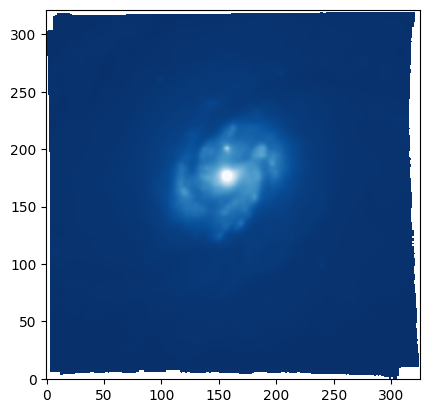

In [152]:
lo,up = np.nanpercentile(stacked_cube,0.05),np.nanpercentile(stacked_cube,99.95)
plt.imshow(stacked_cube, cmap='Blues_r', origin='lower',clim=(lo,up))

In [153]:
wcs = WCS(data[1].header)
print(wcs)

WCS Keywords

Number of WCS axes: 3
CTYPE : 'RA---TAN' 'DEC--TAN' 'AWAV'
CUNIT : 'deg' 'deg' 'm'
CRVAL : 185.728462 15.82182 4.6999658203125e-07
CRPIX : 163.115792247062 165.769472681696 1.0
CD1_1 CD1_2 CD1_3  : -5.55555555555556e-05 0.0 0.0
CD2_1 CD2_2 CD2_3  : 0.0 5.55555555555556e-05 0.0
CD3_1 CD3_2 CD3_3  : 0.0 0.0 1.25e-10
NAXIS : 326  322  3721


In [154]:
from astropy.wcs import WCS
from astropy.io import fits


# getting just the 2D celestial (RA/Dec) part of the WCS
wcs_2d = wcs.celestial


In [155]:

ra_sn = 185.733958#193.713
dec_sn = 15.826119#2.65414

# origin=0 -> numpy/python convention (0-indexed pixels)
x, y = wcs_2d.all_world2pix(ra_sn, dec_sn, 0)

print(x, y)
x=int(x)
y=int(y)

66.9377791239278 242.15271775956978


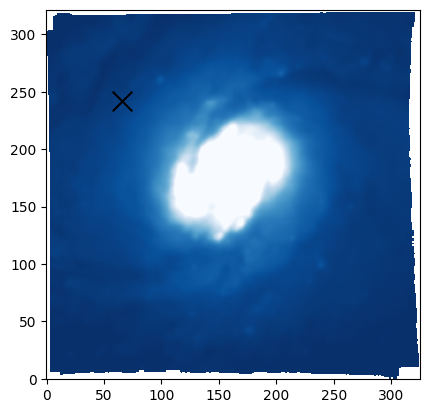

In [156]:
lo,up = np.nanpercentile(stacked_cube,0.05),np.nanpercentile(stacked_cube,99.95)
lo,up = np.nanpercentile(stacked_cube,5),np.nanpercentile(stacked_cube,95)
plt.imshow(stacked_cube, cmap='Blues_r', origin='lower',clim=(lo,up))


plt.scatter(x,y,marker='x',color='black',s=200)

Valid pixels count:  613


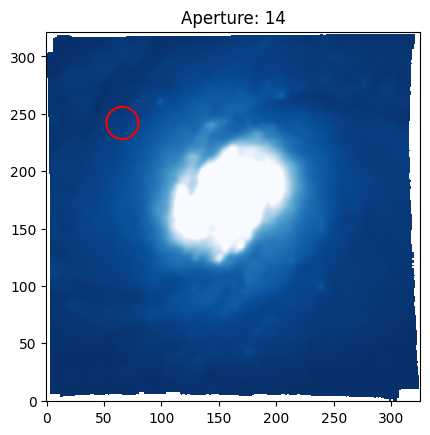

In [181]:
ap=14
spec_ap,pixels=circular_aperture_sum(cube[index-100:index+100,:,:],x,y, radius=ap)
spec_ap_unc = circular_aperture_unc(ecube[index-100:index+100, :, :],x,y,radius=ap)

lo,up = np.nanpercentile(stacked_cube,5),np.nanpercentile(stacked_cube,95)
plt.imshow(stacked_cube, cmap='Blues_r', origin='lower',clim=(lo,up))

 
#plot aperture region


theta = np.linspace(0, 2*np.pi, 500)

x_circle = x + ap * np.cos(theta)
y_circle = y + ap * np.sin(theta)

plt.plot(x_circle, y_circle, 'r-', linewidth=1.5)

#x_ap,y_ap = zip(*pixels)
#plt.scatter(x_ap,y_ap, facecolors='none', edgecolors='red', s=60, linewidths=1.5, alpha=0.8)
plt.title(f"Aperture: {ap}")
plt.show()


#### following is commented, because theres no data for wavelengths around sodium
####out=EW_voronoi_bins(np.asarray([spec_ap]),wave[index-100:index+100],central_wavelength*(1+z),v=500,KS=100,plots=True)

In [ ]:
#CORRER:

Valid pixels count:  13


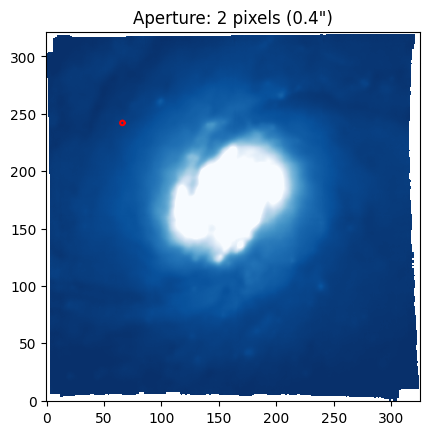

###### Optimize fitting ######


/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/prospect/models/priors.py:125: RuntimeWarning: divide by zero encountered in log
  lnp = np.log(p)


###### dynesty fitting ######
number of walkers=128


/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/prospect/models/priors.py:125: RuntimeWarning: divide by zero encountered in log
  lnp = np.log(p)


done burn #0 (30 iterations)
number of walkers=128
starting production
done production
Median spectrum plotted and saved as median_spectrum.pdf
Valid pixels count:  81


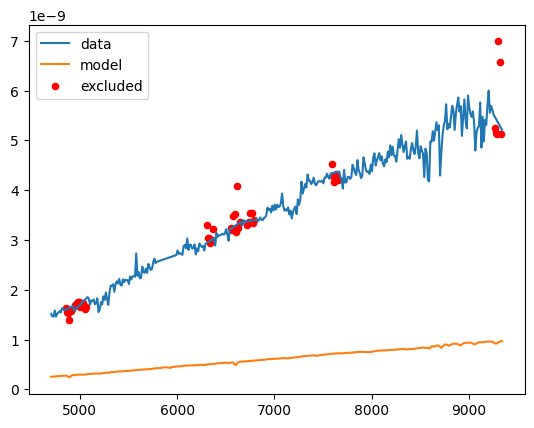

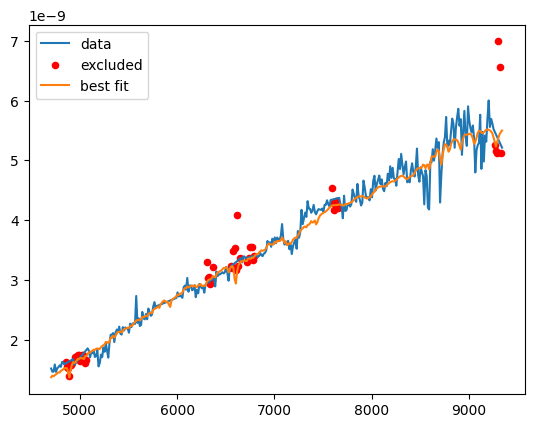

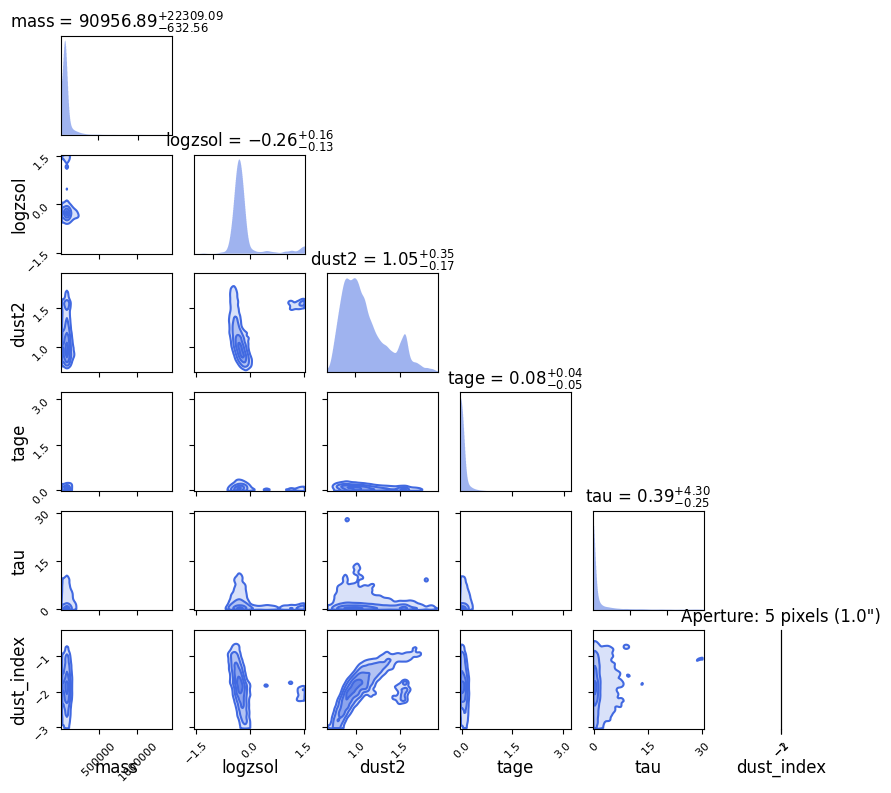

###### Optimize fitting ######


/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/prospect/models/priors.py:125: RuntimeWarning: divide by zero encountered in log
  lnp = np.log(p)


###### dynesty fitting ######
number of walkers=128


/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/prospect/models/priors.py:125: RuntimeWarning: divide by zero encountered in log
  lnp = np.log(p)


done burn #0 (30 iterations)
number of walkers=128
starting production
done production
Median spectrum plotted and saved as median_spectrum.pdf
Valid pixels count:  197


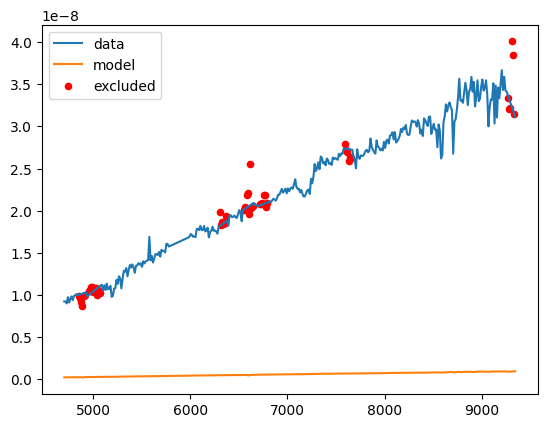

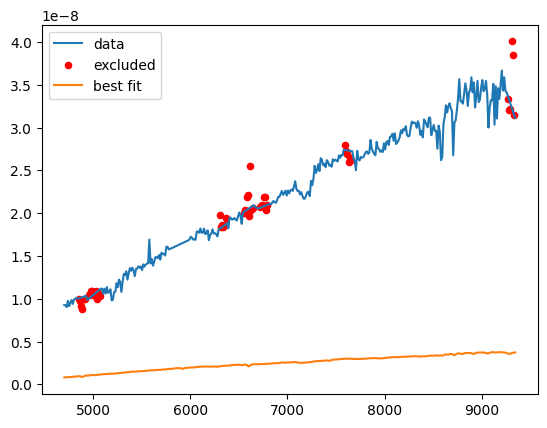

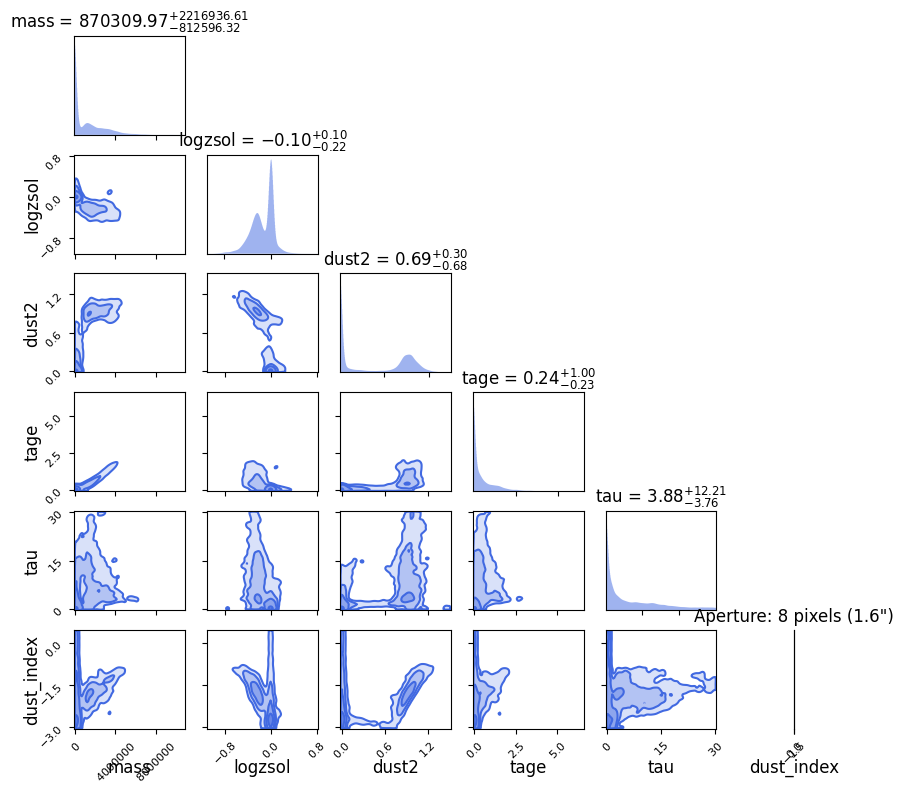

###### Optimize fitting ######


/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/prospect/models/priors.py:125: RuntimeWarning: divide by zero encountered in log
  lnp = np.log(p)


###### dynesty fitting ######
number of walkers=128


/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/prospect/models/priors.py:125: RuntimeWarning: divide by zero encountered in log
  lnp = np.log(p)


done burn #0 (30 iterations)
number of walkers=128
starting production
done production
Median spectrum plotted and saved as median_spectrum.pdf
Valid pixels count:  377


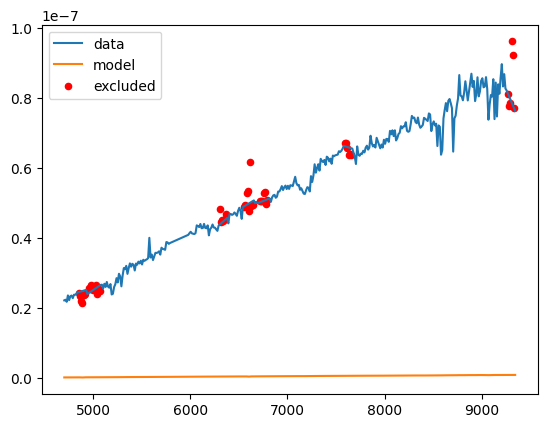

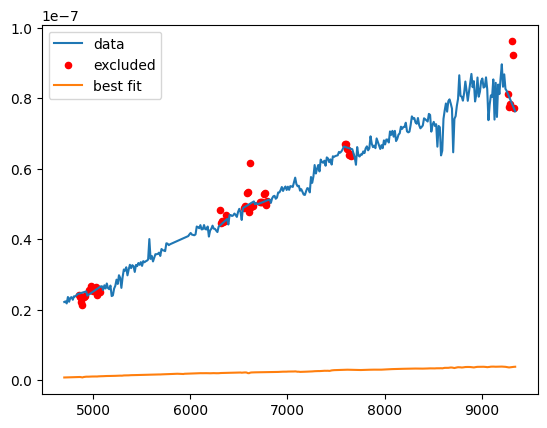

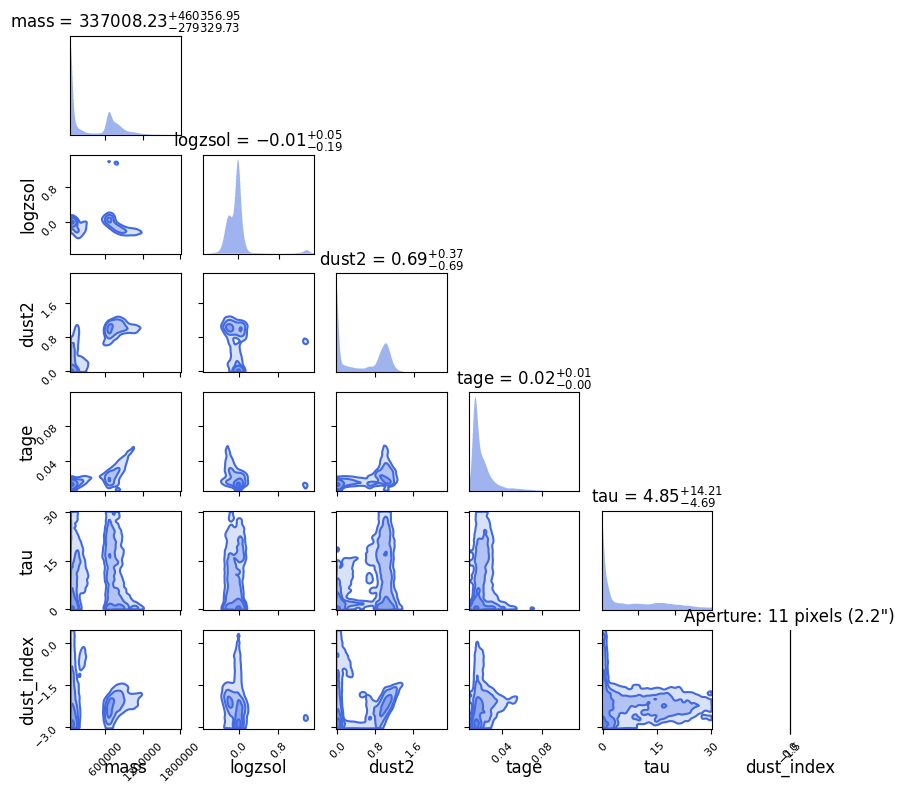

###### Optimize fitting ######


/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/prospect/models/priors.py:125: RuntimeWarning: divide by zero encountered in log
  lnp = np.log(p)


There was an error during the likelihood call at parameters [ 5.46757169e+04  2.39082471e-03  8.70675249e-01  1.06180060e-01
  1.49926984e+00 -2.47821672e+00]
minimizer: Exception while trying to minimize the function:
  params: [ 4.00e+04 -5.00e-01  1.44e+00  1.90e-01  4.20e-01 -7.20e-01]
  args: ()
  exception:


Traceback (most recent call last):
  File "/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/prospect/fitting/minimizer.py", line 22, in __call__
    return self.f(self.func, x, args=self.args,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/scipy/_lib/_util.py", line 717, in inner
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/scipy/optimize/_lsq/least_squares.py", line 1015, in least_squares
    result = call_minpack(vector_fun.fun, x0, vector_fun.jac, ftol, xtol, gtol,
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/scipy/optimize/_lsq/least_squares.py", line 75, in call_minpack
    x, info, status = _minpack._lmder(
                      ^

KeyboardInterrupt: 

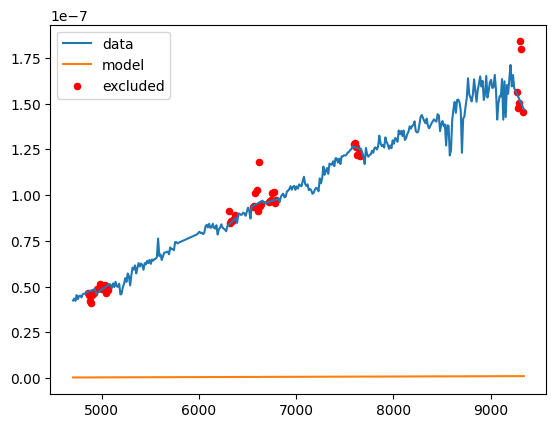

In [212]:
spectra_apertures = []
from run_prospector import *

for ap in [2, 5, 8, 11, 14]:

    #make directory for results
    
    outdir= os.path.join("prospector_fits", f"aperture={ap}")
    os.makedirs(outdir, exist_ok=True)
    
    spec_ap, pixels = circular_aperture_sum(cube, x, y, radius=ap)
    spec_ap_unc = circular_aperture_unc(ecube,x,y,radius=ap)

    #masking adaptive optics wavelenghts, in which f==0:
    mask = spec_ap == 0
    spec_ap[mask] = np.nan
    spec_ap_unc[mask] = np.nan 
    

    spectra_apertures.append({
        "aperture": ap,
        "wave": wave,
        "flux": spec_ap,
        "unc": spec_ap_unc
    })

    # Plot aperture
    lo, up = np.nanpercentile(stacked_cube, 5), np.nanpercentile(stacked_cube, 95)
    plt.imshow(stacked_cube,cmap="Blues_r",origin="lower",clim=(lo, up))

    theta = np.linspace(0, 2*np.pi, 500)
    x_circle = x + ap * np.cos(theta)
    y_circle = y + ap * np.sin(theta)

    plt.plot(x_circle, y_circle, "r-", linewidth=1.5)
    plt.title(f"Aperture: {ap} pixels ({ap*0.2:.1f}\")")

    plt.savefig(outdir+f"/aperture{ap}.pdf", dpi=150, bbox_inches='tight')
    plt.show()
    
    
    
    result = run_prospector_spaxel(spec_ap ,spec_ap_unc,wave,outdir,z=z)
    
    with open(os.path.join(outdir, "output.pkl"), "wb") as f:
        pickle.dump(result, f)

# Save all aperture spectra
#np.save("muse_aperture_spectra.npy", spectra_apertures, allow_pickle=True)

In [ ]:
corrigiiir
# fill the map
for folder in os.listdir(results_dir):
    

    pkl_path = os.path.join(results_dir, folder, "output.pkl")
    
        with open(pkl_path, "rb") as f:
            output = pickle.load(f)

        # extract Av from emcee chain
        sampler = output["sampling"]
        
        flat_chain = sampler.get_chain(flat=True)  # (nsteps*nwalkers, ndim)
        
        # dust2 is your Av proxy - find its index
        # dust2 in maggies units, Av = dust2 * 1.086
        dust2_idx = 2  # adjust if your param order is different
        dust2_chain = flat_chain[:, dust2_idx]
        Av_median = np.median(dust2_chain) * 1.086

        Av_map[y, x] = Av_median
        Av_err_map[y, x] = np.std(dust2_chain) * 1.086
        
        print(f"x={x}, y={y} → Av={Av_median:.3f} +/- {np.std(dust2_chain) * 1.086:.3f}")

    except Exception as e:
        print(f"fail {folder}: {e}")

np.save("Av_map.npy",Av_map)
np.save("Av_err_map.npy",Av_err_map)

In [175]:
y=
x=spectra_apertures[0]['wave']
err=


run_prospector_spaxel(y,cropped_unc[:, i, j],x,pixel=(i, j),z=z)

array([5798.71582031, 5799.96582031, 5801.21582031, 5802.46582031,
       5803.71582031, 5804.96582031, 5806.21582031, 5807.46582031,
       5808.71582031, 5809.96582031, 5811.21582031, 5812.46582031,
       5813.71582031, 5814.96582031, 5816.21582031, 5817.46582031,
       5818.71582031, 5819.96582031, 5821.21582031, 5822.46582031,
       5823.71582031, 5824.96582031, 5826.21582031, 5827.46582031,
       5828.71582031, 5829.96582031, 5831.21582031, 5832.46582031,
       5833.71582031, 5834.96582031, 5836.21582031, 5837.46582031,
       5838.71582031, 5839.96582031, 5841.21582031, 5842.46582031,
       5843.71582031, 5844.96582031, 5846.21582031, 5847.46582031,
       5848.71582031, 5849.96582031, 5851.21582031, 5852.46582031,
       5853.71582031, 5854.96582031, 5856.21582031, 5857.46582031,
       5858.71582031, 5859.96582031, 5861.21582031, 5862.46582031,
       5863.71582031, 5864.96582031, 5866.21582031, 5867.46582031,
       5868.71582031, 5869.96582031, 5871.21582031, 5872.46582

In [528]:
import pandas as pd



df = pd.read_csv("../../DATA/SN2011jm/SN_2011jm_2012-02-02_10-19-12_Lick-3m_KAST_UCB-SNDB_0.flm", sep=r"\s+", header=None)

            0         1         2
0      3444.0  0.355811  0.150399
1      3446.0  0.427993  0.152729
2      3448.0  0.267422  0.151992
3      3450.0  0.259128  0.154231
4      3452.0  0.491634  0.155685
...       ...       ...       ...
3401  10246.0  0.101285  0.110275
3402  10248.0  0.059413  0.112579
3403  10250.0  0.069482  0.114266
3404  10252.0  0.094193  0.115900
3405  10254.0  0.091655  0.115753

[3406 rows x 3 columns]


The wrong flux error was  1.0000619647765359


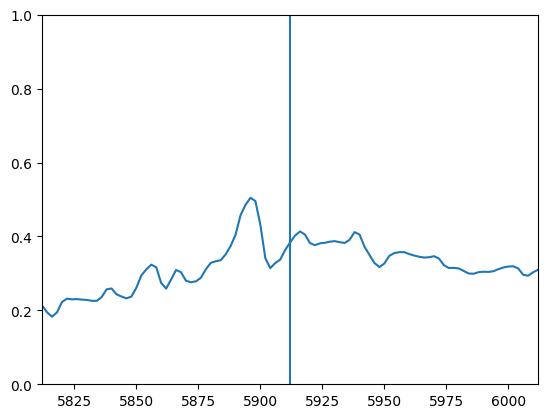

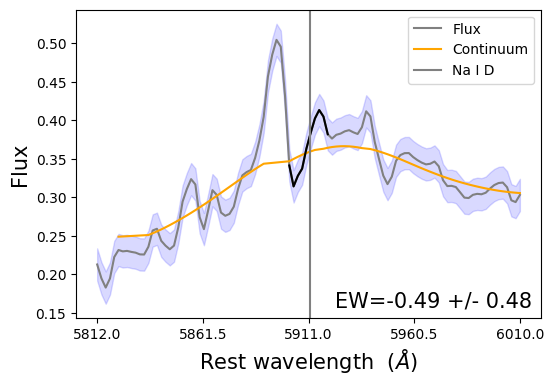


EW= -0.49  +/-  0.4752435284452159

Node separation =  116.0493827160494  Angstrom
SNR of the line is  -1.0304892502401097


([np.float64(-0.4897333473089748)],
 [np.float64(0.4752435284452159)],
 [np.float64(5888.998227293987)])

In [539]:
x = df.iloc[:, 0].to_numpy()
y = df.iloc[:, 1].to_numpy()

plt.plot(x,y)
plt.xlim(na_rest*(1+z)-100,na_rest*(1+z)+100)
plt.axvline(x=na_rest*(1+z))
plt.ylim(0,1)

EW_voronoi_bins(np.asarray([y]),x,central_wavelength*(1+z),v=500,KS=50,plots=True)

In [531]:
x

array([ 3444.,  3446.,  3448., ..., 10250., 10252., 10254.], shape=(3406,))

In [ ]:
------- what i had before:

In [ ]:
wcs = WCS(data[1].header) 

center_x=int(x_len/2)
center_y=int(y_len/2)

?????ra, dec, _ = wcs.all_pix2world(center_x, center_y, 0, 0)

#print(ra,dec)

ra_degrees=185.733958
dec_degrees=15.826119
print("SN occured at ",ra_degrees, dec_degrees)

In [ ]:
#atenção, changed the code here so x is rest wavelength, that is, wave/(1+z)

spec_diff_apertures=[]

for ap in apertures:
    
    y,pixels=circular_aperture_sum(cube[index-100:index+100,:,:],x_nearest,y_nearest, radius=ap)#aqui_sum
    spec_diff_apertures.append(y)
    
    lo,up = np.nanpercentile(cube[index],2),np.nanpercentile(cube[index],98)
    plt.figure(figsize=(10, 8))
    plt.imshow(cube[index],cmap='Blues_r',origin='lower',clim=(lo,up))
    
    #plot aperture region
    x,y = zip(*pixels)
    plt.scatter(x,y, facecolors='none', edgecolors='red', s=60, linewidths=1.5, alpha=0.8)
    plt.title(f"Aperture: {ap}")
    plt.show()
    
out=EW_voronoi_bins(np.array(spec_diff_apertures),np.divide(wave[index-100:index+100],1+z),central_wavelength,v=velocity_window,KS=kernel_size,plots=True,titles=apertures)#central_wavelength*(1+z),v=600,KS=90,plots=True)